In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Modulos Requeridos

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, PReLU, Flatten, Softmax
from tensorflow.keras.models import Model
import numpy as np
import cv2
import matplotlib.pyplot as plt


### Factory

In [ ]:

class NetworkFactory:

    def build_pnet(self, input_shape=None):
        if input_shape is None:
            input_shape = (None, None, 3)

        p_inp = Input(input_shape)

        p_layer = Conv2D(10, kernel_size=(3, 3), strides=(1, 1), padding="valid")(p_inp)
        p_layer = PReLU(shared_axes=[1, 2])(p_layer)
        p_layer = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same")(p_layer)

        p_layer = Conv2D(16, kernel_size=(3, 3), strides=(1, 1), padding="valid")(p_layer)
        p_layer = PReLU(shared_axes=[1, 2])(p_layer)

        p_layer = Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding="valid")(p_layer)
        p_layer = PReLU(shared_axes=[1, 2])(p_layer)

        p_layer_out1 = Conv2D(2, kernel_size=(1, 1), strides=(1, 1))(p_layer)
        p_layer_out1 = Softmax(axis=3)(p_layer_out1)

        p_layer_out2 = Conv2D(4, kernel_size=(1, 1), strides=(1, 1))(p_layer)

        p_net = Model(p_inp, [p_layer_out2, p_layer_out1])

        return p_net

    def build_rnet(self, input_shape=None):
        if input_shape is None:
            input_shape = (24, 24, 3)

        r_inp = Input(input_shape)

        r_layer = Conv2D(28, kernel_size=(3, 3), strides=(1, 1), padding="valid")(r_inp)
        r_layer = PReLU(shared_axes=[1, 2])(r_layer)
        r_layer = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding="same")(r_layer)

        r_layer = Conv2D(48, kernel_size=(3, 3), strides=(1, 1), padding="valid")(r_layer)
        r_layer = PReLU(shared_axes=[1, 2])(r_layer)
        r_layer = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding="valid")(r_layer)

        r_layer = Conv2D(64, kernel_size=(2, 2), strides=(1, 1), padding="valid")(r_layer)
        r_layer = PReLU(shared_axes=[1, 2])(r_layer)
        r_layer = Flatten()(r_layer)
        r_layer = Dense(128)(r_layer)
        r_layer = PReLU()(r_layer)

        r_layer_out1 = Dense(2)(r_layer)
        r_layer_out1 = Softmax(axis=1)(r_layer_out1)

        r_layer_out2 = Dense(4)(r_layer)

        r_net = Model(r_inp, [r_layer_out2, r_layer_out1])

        return r_net

    def build_onet(self, input_shape=None):
        if input_shape is None:
            input_shape = (48, 48, 3)

        o_inp = Input(input_shape)
        o_layer = Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding="valid")(o_inp)
        o_layer = PReLU(shared_axes=[1, 2])(o_layer)
        o_layer = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding="same")(o_layer)

        o_layer = Conv2D(64, kernel_size=(3, 3), strides=(1, 1), padding="valid")(o_layer)
        o_layer = PReLU(shared_axes=[1, 2])(o_layer)
        o_layer = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding="valid")(o_layer)

        o_layer = Conv2D(64, kernel_size=(3, 3), strides=(1, 1), padding="valid")(o_layer)
        o_layer = PReLU(shared_axes=[1, 2])(o_layer)
        o_layer = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same")(o_layer)

        o_layer = Conv2D(128, kernel_size=(2, 2), strides=(1, 1), padding="valid")(o_layer)
        o_layer = PReLU(shared_axes=[1, 2])(o_layer)

        o_layer = Flatten()(o_layer)
        o_layer = Dense(256)(o_layer)
        o_layer = PReLU()(o_layer)

        o_layer_out1 = Dense(2)(o_layer)
        o_layer_out1 = Softmax(axis=1)(o_layer_out1)
        o_layer_out2 = Dense(4)(o_layer)
        o_layer_out3 = Dense(10)(o_layer)

        o_net = Model(o_inp, [o_layer_out2, o_layer_out3, o_layer_out1])
        return o_net

    def build_P_R_O_nets_from_file(self, weights_file):
        weights = np.load(weights_file, allow_pickle=True).tolist()

        p_net = self.build_pnet()
        r_net = self.build_rnet()
        o_net = self.build_onet()

        p_net.set_weights(weights['pnet'])
        r_net.set_weights(weights['rnet'])
        o_net.set_weights(weights['onet'])

        return p_net, r_net, o_net

### Invalid Image

In [ ]:
__author__ = "Iván de Paz Centeno"

class InvalidImage(Exception):
    pass

### MTCNN

In [ ]:

class StageStatus(object):
    """
    Keeps status between MTCNN stages
    """

    def __init__(self, pad_result: tuple = None, width=0, height=0):
        self.width = width
        self.height = height
        self.dy = self.edy = self.dx = self.edx = self.y = self.ey = self.x = self.ex = self.tmpw = self.tmph = []

        if pad_result is not None:
            self.update(pad_result)

    def update(self, pad_result: tuple):
        s = self
        s.dy, s.edy, s.dx, s.edx, s.y, s.ey, s.x, s.ex, s.tmpw, s.tmph = pad_result


class MTCNN(object):
    """
    Allows to perform MTCNN Detection ->
        a) Detection of faces (with the confidence probability)
        b) Detection of keypoints (left eye, right eye, nose, mouth_left, mouth_right)
    """

    def __init__(self, weights_file: str = None, min_face_size: int = 20, steps_threshold: list = None,
                 scale_factor: float = 0.709):
        """
        Initializes the MTCNN.
        :param weights_file: file uri with the weights of the P, R and O networks from MTCNN. By default it will load
        the ones bundled with the package.
        :param min_face_size: minimum size of the face to detect
        :param steps_threshold: step's thresholds values
        :param scale_factor: scale factor
        """
        if steps_threshold is None:
            steps_threshold = [0.6, 0.7, 0.7]

        if weights_file is None:
            weights_file = "/content/drive/MyDrive/Detector Facial/Pesos/mtcnn_weights.npy"

        self._min_face_size = min_face_size
        self._steps_threshold = steps_threshold
        self._scale_factor = scale_factor

        self._pnet, self._rnet, self._onet = NetworkFactory().build_P_R_O_nets_from_file(weights_file)

    @property
    def min_face_size(self):
        return self._min_face_size

    @min_face_size.setter
    def min_face_size(self, mfc=20):
        try:
            self._min_face_size = int(mfc)
        except ValueError:
            self._min_face_size = 20

    def __compute_scale_pyramid(self, m, min_layer):
        scales = []
        factor_count = 0

        while min_layer >= 12:
            scales += [m * np.power(self._scale_factor, factor_count)]
            min_layer = min_layer * self._scale_factor
            factor_count += 1

        return scales

    @staticmethod
    def __scale_image(image, scale: float):
        """
        Scales the image to a given scale.
        :param image:
        :param scale:
        :return:
        """
        height, width, _ = image.shape

        width_scaled = int(np.ceil(width * scale))
        height_scaled = int(np.ceil(height * scale))

        im_data = cv2.resize(image, (width_scaled, height_scaled), interpolation=cv2.INTER_AREA)

        # Normalize the image's pixels
        im_data_normalized = (im_data - 127.5) * 0.0078125

        return im_data_normalized

    @staticmethod
    def __generate_bounding_box(imap, reg, scale, t):

        # use heatmap to generate bounding boxes
        stride = 2
        cellsize = 12

        imap = np.transpose(imap)
        dx1 = np.transpose(reg[:, :, 0])
        dy1 = np.transpose(reg[:, :, 1])
        dx2 = np.transpose(reg[:, :, 2])
        dy2 = np.transpose(reg[:, :, 3])

        y, x = np.where(imap >= t)

        if y.shape[0] == 1:
            dx1 = np.flipud(dx1)
            dy1 = np.flipud(dy1)
            dx2 = np.flipud(dx2)
            dy2 = np.flipud(dy2)

        score = imap[(y, x)]
        reg = np.transpose(np.vstack([dx1[(y, x)], dy1[(y, x)], dx2[(y, x)], dy2[(y, x)]]))

        if reg.size == 0:
            reg = np.empty(shape=(0, 3))

        bb = np.transpose(np.vstack([y, x]))

        q1 = np.fix((stride * bb + 1) / scale)
        q2 = np.fix((stride * bb + cellsize) / scale)
        boundingbox = np.hstack([q1, q2, np.expand_dims(score, 1), reg])

        return boundingbox, reg

    @staticmethod
    def __nms(boxes, threshold, method):
        """
        Non Maximum Suppression.

        :param boxes: np array with bounding boxes.
        :param threshold:
        :param method: NMS method to apply. Available values ('Min', 'Union')
        :return:
        """
        if boxes.size == 0:
            return np.empty((0, 3))

        x1 = boxes[:, 0]
        y1 = boxes[:, 1]
        x2 = boxes[:, 2]
        y2 = boxes[:, 3]
        s = boxes[:, 4]

        area = (x2 - x1 + 1) * (y2 - y1 + 1)
        sorted_s = np.argsort(s)

        pick = np.zeros_like(s, dtype=np.int16)
        counter = 0
        while sorted_s.size > 0:
            i = sorted_s[-1]
            pick[counter] = i
            counter += 1
            idx = sorted_s[0:-1]

            xx1 = np.maximum(x1[i], x1[idx])
            yy1 = np.maximum(y1[i], y1[idx])
            xx2 = np.minimum(x2[i], x2[idx])
            yy2 = np.minimum(y2[i], y2[idx])

            w = np.maximum(0.0, xx2 - xx1 + 1)
            h = np.maximum(0.0, yy2 - yy1 + 1)

            inter = w * h

            if method is 'Min':
                o = inter / np.minimum(area[i], area[idx])
            else:
                o = inter / (area[i] + area[idx] - inter)

            sorted_s = sorted_s[np.where(o <= threshold)]

        pick = pick[0:counter]

        return pick

    @staticmethod
    def __pad(total_boxes, w, h):
        # compute the padding coordinates (pad the bounding boxes to square)
        tmpw = (total_boxes[:, 2] - total_boxes[:, 0] + 1).astype(np.int32)
        tmph = (total_boxes[:, 3] - total_boxes[:, 1] + 1).astype(np.int32)
        numbox = total_boxes.shape[0]

        dx = np.ones(numbox, dtype=np.int32)
        dy = np.ones(numbox, dtype=np.int32)
        edx = tmpw.copy().astype(np.int32)
        edy = tmph.copy().astype(np.int32)

        x = total_boxes[:, 0].copy().astype(np.int32)
        y = total_boxes[:, 1].copy().astype(np.int32)
        ex = total_boxes[:, 2].copy().astype(np.int32)
        ey = total_boxes[:, 3].copy().astype(np.int32)

        tmp = np.where(ex > w)
        edx.flat[tmp] = np.expand_dims(-ex[tmp] + w + tmpw[tmp], 1)
        ex[tmp] = w

        tmp = np.where(ey > h)
        edy.flat[tmp] = np.expand_dims(-ey[tmp] + h + tmph[tmp], 1)
        ey[tmp] = h

        tmp = np.where(x < 1)
        dx.flat[tmp] = np.expand_dims(2 - x[tmp], 1)
        x[tmp] = 1

        tmp = np.where(y < 1)
        dy.flat[tmp] = np.expand_dims(2 - y[tmp], 1)
        y[tmp] = 1

        return dy, edy, dx, edx, y, ey, x, ex, tmpw, tmph

    @staticmethod
    def __rerec(bbox):
        # convert bbox to square
        height = bbox[:, 3] - bbox[:, 1]
        width = bbox[:, 2] - bbox[:, 0]
        max_side_length = np.maximum(width, height)
        bbox[:, 0] = bbox[:, 0] + width * 0.5 - max_side_length * 0.5
        bbox[:, 1] = bbox[:, 1] + height * 0.5 - max_side_length * 0.5
        bbox[:, 2:4] = bbox[:, 0:2] + np.transpose(np.tile(max_side_length, (2, 1)))
        return bbox

    @staticmethod
    def __bbreg(boundingbox, reg):
        # calibrate bounding boxes
        if reg.shape[1] == 1:
            reg = np.reshape(reg, (reg.shape[2], reg.shape[3]))

        w = boundingbox[:, 2] - boundingbox[:, 0] + 1
        h = boundingbox[:, 3] - boundingbox[:, 1] + 1
        b1 = boundingbox[:, 0] + reg[:, 0] * w
        b2 = boundingbox[:, 1] + reg[:, 1] * h
        b3 = boundingbox[:, 2] + reg[:, 2] * w
        b4 = boundingbox[:, 3] + reg[:, 3] * h
        boundingbox[:, 0:4] = np.transpose(np.vstack([b1, b2, b3, b4]))
        return boundingbox

    def detect_faces(self, img) -> list:
        """
        Detects bounding boxes from the specified image.
        :param img: image to process
        :return: list containing all the bounding boxes detected with their keypoints.
        """
        if img is None or not hasattr(img, "shape"):
            raise InvalidImage("Image not valid.")

        height, width, _ = img.shape
        stage_status = StageStatus(width=width, height=height)

        m = 12 / self._min_face_size
        min_layer = np.amin([height, width]) * m

        scales = self.__compute_scale_pyramid(m, min_layer)

        stages = [self.__stage1, self.__stage2, self.__stage3]
        result = [scales, stage_status]

        # We pipe here each of the stages
        for stage in stages:
            result = stage(img, result[0], result[1])

        [total_boxes, points] = result

        bounding_boxes = []

        for bounding_box, keypoints in zip(total_boxes, points.T):
            x = max(0, int(bounding_box[0]))
            y = max(0, int(bounding_box[1]))
            width = int(bounding_box[2] - x)
            height = int(bounding_box[3] - y)
            bounding_boxes.append({
                'box': [x, y, width, height],
                'confidence': bounding_box[-1],
                'keypoints': {
                    'left_eye': (int(keypoints[0]), int(keypoints[5])),
                    'right_eye': (int(keypoints[1]), int(keypoints[6])),
                    'nose': (int(keypoints[2]), int(keypoints[7])),
                    'mouth_left': (int(keypoints[3]), int(keypoints[8])),
                    'mouth_right': (int(keypoints[4]), int(keypoints[9])),
                }
            })

        return bounding_boxes

    def __stage1(self, image, scales: list, stage_status: StageStatus):
        """
        First stage of the MTCNN.
        :param image:
        :param scales:
        :param stage_status:
        :return:
        """
        total_boxes = np.empty((0, 9))
        status = stage_status

        for scale in scales:
            scaled_image = self.__scale_image(image, scale)

            img_x = np.expand_dims(scaled_image, 0)
            img_y = np.transpose(img_x, (0, 2, 1, 3))

            out = self._pnet.predict(img_y)

            out0 = np.transpose(out[0], (0, 2, 1, 3))
            out1 = np.transpose(out[1], (0, 2, 1, 3))

            boxes, _ = self.__generate_bounding_box(out1[0, :, :, 1].copy(),
                                                    out0[0, :, :, :].copy(), scale, self._steps_threshold[0])

            # inter-scale nms
            pick = self.__nms(boxes.copy(), 0.5, 'Union')
            if boxes.size > 0 and pick.size > 0:
                boxes = boxes[pick, :]
                total_boxes = np.append(total_boxes, boxes, axis=0)

        numboxes = total_boxes.shape[0]

        if numboxes > 0:
            pick = self.__nms(total_boxes.copy(), 0.7, 'Union')
            total_boxes = total_boxes[pick, :]

            regw = total_boxes[:, 2] - total_boxes[:, 0]
            regh = total_boxes[:, 3] - total_boxes[:, 1]

            qq1 = total_boxes[:, 0] + total_boxes[:, 5] * regw
            qq2 = total_boxes[:, 1] + total_boxes[:, 6] * regh
            qq3 = total_boxes[:, 2] + total_boxes[:, 7] * regw
            qq4 = total_boxes[:, 3] + total_boxes[:, 8] * regh

            total_boxes = np.transpose(np.vstack([qq1, qq2, qq3, qq4, total_boxes[:, 4]]))
            total_boxes = self.__rerec(total_boxes.copy())

            total_boxes[:, 0:4] = np.fix(total_boxes[:, 0:4]).astype(np.int32)
            status = StageStatus(self.__pad(total_boxes.copy(), stage_status.width, stage_status.height),
                                 width=stage_status.width, height=stage_status.height)

        return total_boxes, status

    def __stage2(self, img, total_boxes, stage_status: StageStatus):
        """
        Second stage of the MTCNN.
        :param img:
        :param total_boxes:
        :param stage_status:
        :return:
        """

        num_boxes = total_boxes.shape[0]
        if num_boxes == 0:
            return total_boxes, stage_status

        # second stage
        tempimg = np.zeros(shape=(24, 24, 3, num_boxes))

        for k in range(0, num_boxes):
            tmp = np.zeros((int(stage_status.tmph[k]), int(stage_status.tmpw[k]), 3))

            tmp[stage_status.dy[k] - 1:stage_status.edy[k], stage_status.dx[k] - 1:stage_status.edx[k], :] = \
                img[stage_status.y[k] - 1:stage_status.ey[k], stage_status.x[k] - 1:stage_status.ex[k], :]

            if tmp.shape[0] > 0 and tmp.shape[1] > 0 or tmp.shape[0] == 0 and tmp.shape[1] == 0:
                tempimg[:, :, :, k] = cv2.resize(tmp, (24, 24), interpolation=cv2.INTER_AREA)

            else:
                return np.empty(shape=(0,)), stage_status

        tempimg = (tempimg - 127.5) * 0.0078125
        tempimg1 = np.transpose(tempimg, (3, 1, 0, 2))

        out = self._rnet.predict(tempimg1)

        out0 = np.transpose(out[0])
        out1 = np.transpose(out[1])

        score = out1[1, :]

        ipass = np.where(score > self._steps_threshold[1])

        total_boxes = np.hstack([total_boxes[ipass[0], 0:4].copy(), np.expand_dims(score[ipass].copy(), 1)])

        mv = out0[:, ipass[0]]

        if total_boxes.shape[0] > 0:
            pick = self.__nms(total_boxes, 0.7, 'Union')
            total_boxes = total_boxes[pick, :]
            total_boxes = self.__bbreg(total_boxes.copy(), np.transpose(mv[:, pick]))
            total_boxes = self.__rerec(total_boxes.copy())

        return total_boxes, stage_status

    def __stage3(self, img, total_boxes, stage_status: StageStatus):
        """
        Third stage of the MTCNN.

        :param img:
        :param total_boxes:
        :param stage_status:
        :return:
        """
        num_boxes = total_boxes.shape[0]
        if num_boxes == 0:
            return total_boxes, np.empty(shape=(0,))

        total_boxes = np.fix(total_boxes).astype(np.int32)

        status = StageStatus(self.__pad(total_boxes.copy(), stage_status.width, stage_status.height),
                             width=stage_status.width, height=stage_status.height)

        tempimg = np.zeros((48, 48, 3, num_boxes))

        for k in range(0, num_boxes):

            tmp = np.zeros((int(status.tmph[k]), int(status.tmpw[k]), 3))

            tmp[status.dy[k] - 1:status.edy[k], status.dx[k] - 1:status.edx[k], :] = \
                img[status.y[k] - 1:status.ey[k], status.x[k] - 1:status.ex[k], :]

            if tmp.shape[0] > 0 and tmp.shape[1] > 0 or tmp.shape[0] == 0 and tmp.shape[1] == 0:
                tempimg[:, :, :, k] = cv2.resize(tmp, (48, 48), interpolation=cv2.INTER_AREA)
            else:
                return np.empty(shape=(0,)), np.empty(shape=(0,))

        tempimg = (tempimg - 127.5) * 0.0078125
        tempimg1 = np.transpose(tempimg, (3, 1, 0, 2))

        out = self._onet.predict(tempimg1)
        out0 = np.transpose(out[0])
        out1 = np.transpose(out[1])
        out2 = np.transpose(out[2])

        score = out2[1, :]

        points = out1

        ipass = np.where(score > self._steps_threshold[2])

        points = points[:, ipass[0]]

        total_boxes = np.hstack([total_boxes[ipass[0], 0:4].copy(), np.expand_dims(score[ipass].copy(), 1)])

        mv = out0[:, ipass[0]]

        w = total_boxes[:, 2] - total_boxes[:, 0] + 1
        h = total_boxes[:, 3] - total_boxes[:, 1] + 1

        points[0:5, :] = np.tile(w, (5, 1)) * points[0:5, :] + np.tile(total_boxes[:, 0], (5, 1)) - 1
        points[5:10, :] = np.tile(h, (5, 1)) * points[5:10, :] + np.tile(total_boxes[:, 1], (5, 1)) - 1

        if total_boxes.shape[0] > 0:
            total_boxes = self.__bbreg(total_boxes.copy(), np.transpose(mv))
            pick = self.__nms(total_boxes.copy(), 0.7, 'Min')
            total_boxes = total_boxes[pick, :]
            points = points[:, pick]

        return total_boxes, points

<>:165: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:165: SyntaxWarning: "is" with a literal. Did you mean "=="?
<ipython-input-7-8b4b1ad98161>:165: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if method is 'Min':


## Despliegue del modelo

In [ ]:
# Inicializar el detector de MTCNN
detector = MTCNN()

def detect_faces(image):
    """Detecta caras en una imagen usando MTCNN."""
    results = detector.detect_faces(image)
    return results

def draw_boxes(image, detections):
    """Dibuja rectángulos alrededor de las caras detectadas en la imagen."""
    for result in detections:
        x, y, width, height = result['box']
        cv2.rectangle(image, (x, y), (x + width, y + height), (0, 255, 0), 2)
    return image

def extract_faces(image, detections):
    """Extrae y guarda las caras detectadas en imágenes separadas."""
    faces = []
    for i, result in enumerate(detections):
        x, y, width, height = result['box']
        face = image[y:y+height, x:x+width]
        faces.append(face)
        # Guardar cada cara detectada como una imagen separada
        face_filename = f'face_{i}.jpg'
        cv2.imwrite(face_filename, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
    return faces

In [ ]:
image_path = "/content/drive/MyDrive/Arc Face/Fotos/k2.PNG"

1/1 [==============================] - 0s 46ms/step


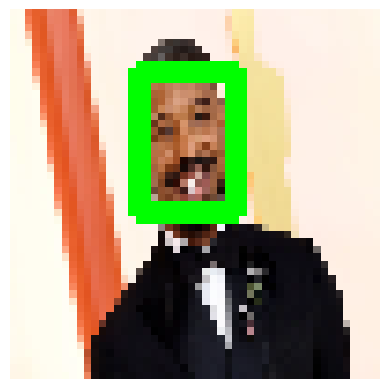

In [ ]:
# Leer y procesar la imagen
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_rgb = cv2.resize(image_rgb, (50, 50))

detections = detect_faces(image_rgb)
image_with_boxes = draw_boxes(image_rgb.copy(), detections)

# Mostrar la imagen con las caras detectadas
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()

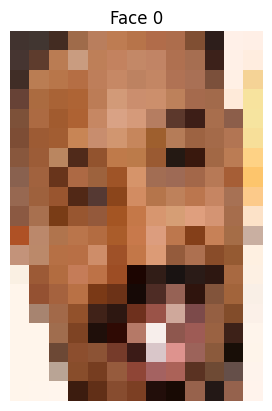

In [ ]:
# Mostrar cada una de las caras extraídas
faces = extract_faces(image_rgb, detections)
for i, face in enumerate(faces):
    plt.figure()
    plt.imshow(face)
    plt.axis('off')
    plt.title(f'Face {i}')
    plt.show()

In [ ]:
image_rgb.shape

(50, 50, 3)

In [ ]:
faces[0]

array([[[ 65,  51,  47],
        [ 65,  54,  49],
        [ 67,  44,  34],
        [159, 107,  74],
        [185, 126,  93],
        [190, 124,  82],
        [183, 116,  74],
        [177, 108,  74],
        [173, 109,  76],
        [128,  79,  51],
        [ 45,  30,  27],
        [255, 240, 232],
        [255, 239, 230]],

       [[ 70,  53,  49],
        [ 94,  60,  45],
        [186, 124,  83],
        [201, 156, 128],
        [190, 127,  88],
        [195, 130,  95],
        [195, 136, 103],
        [193, 132, 101],
        [175, 112,  80],
        [166, 110,  81],
        [ 60,  33,  26],
        [255, 240, 231],
        [255, 237, 223]],

       [[ 64,  45,  38],
        [186, 125,  83],
        [184, 118,  74],
        [181, 110,  68],
        [190, 126,  90],
        [198, 136, 101],
        [189, 130,  97],
        [195, 134, 100],
        [176, 114,  84],
        [169, 112,  85],
        [123,  80,  59],
        [255, 240, 229],
        [245, 211, 150]],

       [[103,  66,  54],
        [171, 107,  64],
        [169,  99,  54],
        [174, 100,  53],
        [188, 124,  86],
        [210, 154, 120],
        [203, 142, 110],
        [204, 143, 108],
        [189, 129,  91],
        [165, 106,  77],
        [162, 106,  75],
        [254, 234, 217],
        [247, 227, 158]],

       [[125,  81,  57],
        [172, 106,  66],
        [161,  91,  47],
        [174,  98,  51],
        [198, 135,  99],
        [217, 162, 133],
        [213, 154, 122],
        [181, 125,  97],
        [ 92,  56,  44],
        [ 61,  30,  23],
        [168, 110,  77],
        [140,  94,  74],
        [246, 228, 159]],

       [[125,  77,  53],
        [157,  91,  52],
        [162,  93,  50],
        [200, 133,  85],
        [200, 141, 110],
        [209, 150, 112],
        [198, 134,  92],
        [158,  95,  46],
        [181, 124,  88],
        [157,  99,  66],
        [164, 106,  73],
        [178, 117,  83],
        [247, 223, 153]],

       [[136,  87,  61],
        [156,  92,  55],
        [186, 134,  96],
        [ 80,  42,  26],
        [146,  83,  46],
        [191, 122,  74],
        [188, 123,  74],
        [154,  90,  50],
        [ 36,  25,  19],
        [ 57,  24,  13],
        [162, 104,  69],
        [187, 124,  84],
        [254, 210, 133]],

       [[137,  97,  79],
        [161,  98,  62],
        [104,  52,  27],
        [173, 105,  68],
        [157,  98,  61],
        [159,  84,  39],
        [214, 148, 106],
        [162, 109,  83],
        [158, 106,  85],
        [163, 103,  73],
        [183, 121,  86],
        [166,  94,  54],
        [253, 197, 108]],

       [[151, 104,  81],
        [158,  97,  61],
        [153,  85,  47],
        [ 81,  40,  22],
        [ 85,  57,  51],
        [139,  69,  27],
        [210, 140,  98],
        [181, 117,  75],
        [190, 129,  91],
        [187, 118,  78],
        [198, 133,  98],
        [167, 113,  84],
        [252, 202, 138]],

       [[139,  89,  66],
        [168, 112,  79],
        [121,  60,  22],
        [152,  86,  48],
        [148,  89,  59],
        [164,  85,  35],
        [197, 120,  72],
        [215, 150, 111],
        [214, 158, 117],
        [223, 159, 126],
        [212, 148, 115],
        [166, 109,  76],
        [252, 226, 200]],

       [[175,  81,  37],
        [187, 136, 107],
        [176, 116,  77],
        [186, 117,  75],
        [179, 108,  65],
        [170,  92,  42],
        [200, 121,  75],
        [220, 157, 126],
        [189, 119,  77],
        [132,  63,  25],
        [199, 129,  87],
        [165, 109,  71],
        [201, 175, 161]],

       [[195, 147, 122],
        [187, 137, 106],
        [182, 112,  69],
        [184, 111,  69],
        [206, 141, 105],
        [159,  81,  40],
        [195, 119,  72],
        [220, 155, 118],
        [148,  91,  60],
        [173, 112,  80],
        [137,  76,  41],
        [149,  90,  50],
        [254, 240, 225]],

       [[250, 240, 227],
        [156,  90,  54],
        [178, 108,  64],
 